In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())

from torchvision.datasets import ImageFolder
from torch.utils.data import ConcatDataset


transform = transforms.Compose([
    transforms.Resize((256, 256)),   # resize H × W
    transforms.ToTensor()             # converts to (C, H, W)
])

dataset = ImageFolder(
    "data/Cat_Dog_data/train",
    transform=transform
)
test_data = ImageFolder(
    "data/Cat_Dog_data/test",
    transform=transform
)

False


torch.Size([3, 256, 256])
0 cat
(256, 256, 3)


(-0.5, 255.5, 255.5, -0.5)

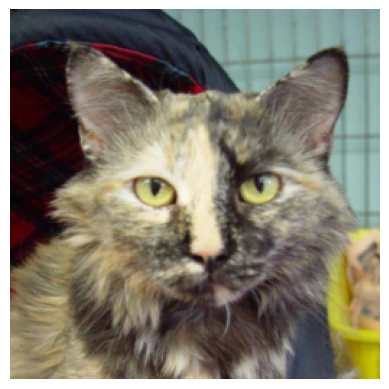

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
import cv2
import numpy as np
import matplotlib.pyplot as plt

img, label = dataset[2]
print(img.shape)  # (3, H, W)

# Convert to HWC for OpenCV / matplotlib
img = img.permute(1, 2, 0).numpy()

# Resize (OpenCV expects width, height)
img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)

print(label, dataset.classes[label])
print(img.shape)  # (256, 256, 3)

plt.imshow(img)
plt.axis("off")

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
num_pixels = 0 
channel_sum = torch.zeros(3)
for images, labels in dataset:
    # images: (3, H, W)
    c, h, w = images.shape

    num_pixels +=  h * w

    channel_sum += images.sum(dim=(1,2))
channel_sum = channel_sum/num_pixels
    
print(channel_sum)

tensor([0.4902, 0.4536, 0.4169])


(-0.5, 255.5, 255.5, -0.5)

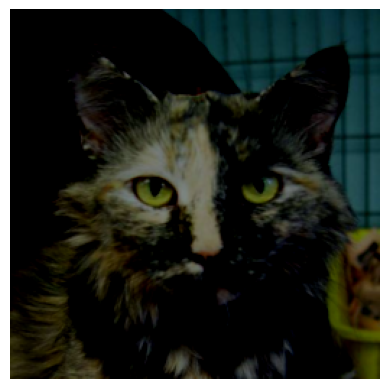

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
mean = channel_sum.to(device)
std  = torch.tensor([1, 1, 1]).to(device)

def normalizeimg(image):
    image_norm = (image - mean[:, None, None]) / std[:, None, None]
    return image_norm
image,label = dataset[2]
image = normalizeimg(image.to(device))
image = image.permute(1, 2, 0).detach().cpu().numpy()

plt.imshow(image)
plt.axis("off")

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
import torch
import torchvision.transforms.functional as TF
import random
import itertools

# Precompute all RGB permutations
_RGB_PERMS = list(itertools.permutations([0, 1, 2]))  # 6 perms

import torch
import random
import torchvision.transforms.functional as TF

def data_aug(
    images,
    p_flip=0.5,
    max_rotation=10,
    p_rgb_permute=0
):
    """
    Args:
        images: (B, 3, H, W), values in [0, 1]
    Returns:
        (B, 3, H, W)
    """

    assert images.dim() == 4, "Expected batch tensor (B, 3, H, W)"
    assert images.shape[1] == 3, "Expected RGB images"

    auged = []

    for img in images:  # img: (3, H, W)
        img = normalizeimg(img)

        # flips
        if random.random() < p_flip:
            img = TF.hflip(img)
        if random.random() < p_flip:
            img = TF.vflip(img)

        # color jitter
        img = TF.adjust_brightness(img, random.uniform(0.8, 1.2))
        img = TF.adjust_contrast(img,  random.uniform(0.8, 1.2))
        img = TF.adjust_saturation(img, random.uniform(0.8, 1.2))

        # rotation
        #angle = random.uniform(-max_rotation, max_rotation)
        #img = TF.rotate(img, angle)

        # RGB permutation
        #if random.random() < p_rgb_permute:
            #perm = torch.randperm(3)
            #img = img[perm]

        auged.append(img)

    return torch.stack(auged)

print("hi")

hi


(-0.5, 255.5, 255.5, -0.5)

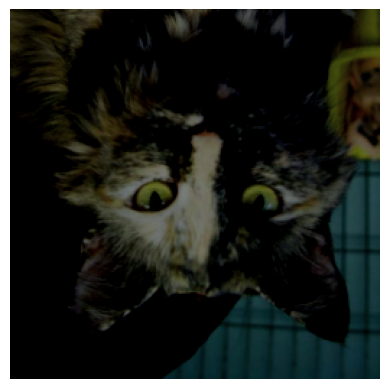

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
image, label = dataset[2]

image = torch.stack([image])              # (1, 3, H, W)
image = data_aug(image.to(device))        # (1, 3, H, W)

image = image.squeeze(0)                  # (3, H, W)
image = image.permute(1, 2, 0)             # (H, W, 3)

image = image.detach().cpu().numpy()

plt.imshow(image)
plt.axis("off")

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
print("hi")
batch_size = 64
learning_rate = 0.001

train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                          shuffle=True)

test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
                                         shuffle=False)
n_total_steps = len(train_loader)
n_test_steps = len(test_loader)
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3,16,3,1,1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16,32,5,1,2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32,64,7,1,3)
        self.bn3 = nn.BatchNorm2d(64)
        self.l1 = nn.Linear(32*32*64,512)
        self.l2 = nn.Linear(512,16)
        self.l3 = nn.Linear(16,2)
        self.maxpool = nn.MaxPool2d(2, 2)
        self.loss_history = [] 
        self.lr_history = [] 
    def test(self):
        self.eval()  # switch to eval mode
    
        total_loss = 0.0
        correct = 0
        total = 0
    
        with torch.no_grad():  # no gradients during evaluation
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                images = normalizeimg(images)
    
                outputs = self(images)              # forward
                loss = criterion(outputs, labels)   # loss
    
                total_loss += loss.item()
    
                _, predicted = torch.max(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
    
        avg_loss = total_loss / len(test_loader)
        accuracy = 100.0 * correct / total
    
        print(f'loss = {avg_loss}, acc = {accuracy}%')


        
    def forward(self, x):
            # x: (N, 3, 256, 256)
        
            out = self.conv1(x)
            #out = self.bn1(out)
            out = F.relu(out)
            out = self.maxpool(out)      # (N, 64, 128, 128)
        
            out = self.conv2(out)
            #out = self.bn2(out)
            out = F.relu(out)
            out = self.maxpool(out)      # (N, 32, 64, 64)
        
            out = self.conv3(out)
            #out = self.bn3(out)
            out = F.relu(out)
            out = self.maxpool(out)      # (N, 16, 32, 32)
        
            out = out.view(out.size(0), -1)  # flatten (N,32*16*16)
            out = self.l1(out)
            out = F.relu(out)
            out = self.l2(out)
            out = F.relu(out)
            out = self.l3(out)
            return out 
    def manange_lr(self):
        pass
        





        #self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        #self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        #self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        #self.fc1 = nn.Linear(64 * 37 * 37, 512)  # Adjusted input size based on the output of conv2
        #self.fc2 = nn.Linear(512, num_classes)

hi


In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
model = CNN().to(device)
sum(p.numel() for p in model.parameters())
3,367,7106

(3, 367, 7106)

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
import torch.optim as optim
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())
PATH = 'data/parameters'

False


In [10]:
# --- [CELL 9]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
# === BEFORE (original) ===
# optimizer = optim.Adam(model.parameters())
# print(optimizer.lr)

# === AFTER (edited) ===
optimizer = optim.Adam(model.parameters())
print(optimizer.param_groups[0]['lr'])

0.001


In [11]:
# Verify PyTorch optimizer LR is accessed through param_groups and is valid.
assert 'optimizer' in globals(), "optimizer should be created in the previous cell"
assert len(optimizer.param_groups) > 0, "optimizer should have at least one parameter group"
lr = optimizer.param_groups[0]['lr']
assert isinstance(lr, float), "learning rate should be a float"
assert lr > 0, "learning rate must be positive"